# Stage 1 - Basic Blog Writing Agent (Orchestrator-Worker pattern)

```
__start__ -> orchestrator -> worker(s) -> reducer -> __end__
```

- **orchestrator** — plans the blog. Produces a `Plan` (`blog_title` + a list of
  `Task` sections), each with an `id`, `title`, and `brief`.
- **worker** — one worker per task, dispatched dynamically via `Send()`.
  Each worker writes the markdown content for its single section.
- **reducer** — stitches all sections back together in `id` order into one
  markdown document and writes it to disk.

State has exactly 4 fields: `topic`, `plan`, `sections`, `final`.


In [14]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant")

# llama-3.1-8b-instant doesn't support method="json_schema" on Groq, so a
# separate model handles the orchestrator's structured `Plan` output.
structured_llm = ChatGroq(model="openai/gpt-oss-20b")

In [15]:
from pydantic import BaseModel, Field


class Task(BaseModel):
    id: int = Field(description="Order of this section in the blog, starting at 1")
    title: str = Field(description="Section heading")
    brief: str = Field(description="What this section should cover")


class Plan(BaseModel):
    blog_title: str = Field(description="Title of the overall blog post")
    tasks: list[Task] = Field(
        description="Ordered list of sections that make up the blog"
    )


planner_model = structured_llm.with_structured_output(Plan, method="json_schema")

In [16]:
import operator
from typing import Annotated, TypedDict


class WorkerState(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[list[dict], operator.add]
    final: str

In [17]:
def orchestrator(state: WorkerState) -> WorkerState:
    prompt = (
        f"Plan a blog post about: {state['topic']}\n\n"
        "Come up with a clear blog title and break the post into an ordered "
        "list of sections. Each section needs an id (starting at 1, in the "
        "order it should appear), a title, and a brief describing what that "
        "section should cover."
    )
    plan = planner_model.invoke(prompt)
    return {"plan": plan}

In [18]:
from langgraph.types import Send


def assign_workers(state: WorkerState) -> list[Send]:
    return [
        Send("worker", {"blog_title": state["plan"].blog_title, "task": task})
        for task in state["plan"].tasks
    ]

In [19]:
def worker(state: WorkerState) -> WorkerState:
    task = state["task"]
    prompt = (
        f"Blog title: {state['blog_title']}\n"
        f"Section: {task.title}\n"
        f"Brief: {task.brief}\n\n"
        "Write the markdown content for just this section (no title heading, "
        "just the body text)."
    )
    content = model.invoke(prompt).content
    return {"sections": [{"id": task.id, "title": task.title, "content": content}]}

In [20]:
def reducer(state: WorkerState) -> WorkerState:
    sections = sorted(state["sections"], key=lambda s: s["id"])

    body = "\n\n".join(f"## {s['title']}\n\n{s['content']}" for s in sections)
    markdown = f"# {state['plan'].blog_title}\n\n{body}\n"

    slug = state["plan"].blog_title.lower().replace(" ", "_")
    output_path = f"{slug}.md"
    with open(output_path, "w") as f:
        f.write(markdown)

    return {"final": markdown}

In [21]:
from langgraph.graph import END, START, StateGraph

graph = StateGraph(WorkerState)

graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)

graph.add_edge(START, "orchestrator")
graph.add_conditional_edges("orchestrator", assign_workers, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

workflow = graph.compile()

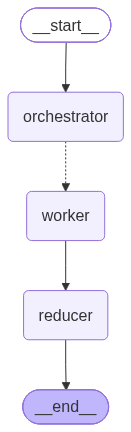

In [22]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [23]:
final_state = workflow.invoke(
    {"topic": "Why LangGraph is useful for building agentic workflows"}
)
print(final_state["final"])

# Why LangGraph is Useful for Building Agentic Workflows

## Introduction to Agentic Workflows

Agentic workflows refer to a type of workflow architecture that emphasizes autonomy, adaptability, and agency – essentially giving components or systems the ability to make decisions and take actions based on their context, goals, and environment. This concept is rooted in the idea that complex systems can benefit from decentralized decision-making, allowing them to respond more effectively to changing conditions and unforeseen events.

In traditional workflow management systems, tasks and processes are often predetermined and rigidly structured, with limited room for deviation or adaptation. However, agentic workflows recognize that real-world processes are inherently dynamic and require a more flexible approach to ensure efficiency, resilience, and scalability.

The importance of agentic workflows lies in their ability to address the increasing complexity of modern systems, where automatio